In [ ]:
from pathlib import Path
import wave
import contextlib
import pandas as pd

# Base folder that contains class subfolders (asthma, copd, etc.)
base_data_dir = Path("data")

label_map = {
    "asthma": "Asthma",
    "copd": "COPD",
    "bronchial": "Bronchial",
    "pneumonia": "Pneumonia",
    "healthy": "Healthy",
}

rows = []

for wav_path in base_data_dir.rglob("*.wav"):
    folder_name = wav_path.parent.name.lower()
    label = label_map.get(folder_name, wav_path.parent.name)

    with contextlib.closing(wave.open(str(wav_path), "rb")) as wav_file:
        sample_rate = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / float(sample_rate) if sample_rate else 0.0

    # Relative path inside the stage after PUT data/*.wav @audio_stage
    file_path = str(wav_path.as_posix())

    rows.append(
        {
            "file_name": wav_path.name,
            "label": label,
            "duration_sec": duration_sec,
            "sample_rate": sample_rate,
            "file_path": file_path,
        }
    )

df = pd.DataFrame(rows).sort_values(["label", "file_name"]).reset_index(drop=True)
df

,file_name,label,duration_sec,sample_rate,file_path
0,P10AsthmaIE_49.wav,Asthma,3.136,4000,data/asthma/P10AsthmaIE_49.wav
1,P10AsthmaIU_46.wav,Asthma,4.944,4000,data/asthma/P10AsthmaIU_46.wav
2,P10AsthmaIU_50.wav,Asthma,6.000,4000,data/asthma/P10AsthmaIU_50.wav
3,P10AsthmaRL_47.wav,Asthma,6.000,4000,data/asthma/P10AsthmaRL_47.wav
4,P10AsthmaRS_48.wav,Asthma,6.000,4000,data/asthma/P10AsthmaRS_48.wav
5,P11WheezingIE_53.wav,Asthma,6.000,4000,data/asthma/P11WheezingIE_53.wav
6,P11WheezingIU_54.wav,Asthma,6.000,4000,data/asthma/P11WheezingIU_54.wav
7,P11WheezingRL_51.wav,Asthma,5.952,4000,data/asthma/P11WheezingRL_51.wav
8,P11WheezingRL_55.wav,Asthma,5.536,4000,data/asthma/P11WheezingRL_55.wav
9,P11WheezingRS_52.wav,Asthma,6.000,4000,data/asthma/P11WheezingRS_52.wav


In [15]:
df['sample_rate'].value_counts()

sample_rate
44100    707
4000     504
Name: count, dtype: int64

In [21]:
df[df['sample_rate'] != 4000]['label'].value_counts()

label
Pneumonia    246
COPD         213
Healthy      133
Bronchial     89
Asthma        26
Name: count, dtype: int64

# VIsualisation

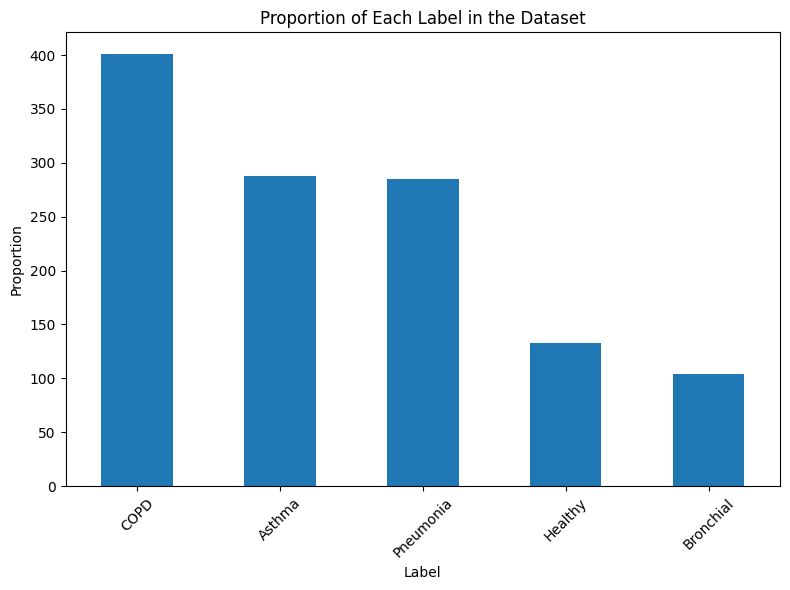

In [17]:
label_counts = df["label"].value_counts()
label_proportions = label_counts / label_counts.sum()
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
label_counts.plot(kind="bar")
plt.title("Proportion of Each Label in the Dataset")
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Création des spectres


=== Waveform Examples for Each Category (Normalized Y scale) ===


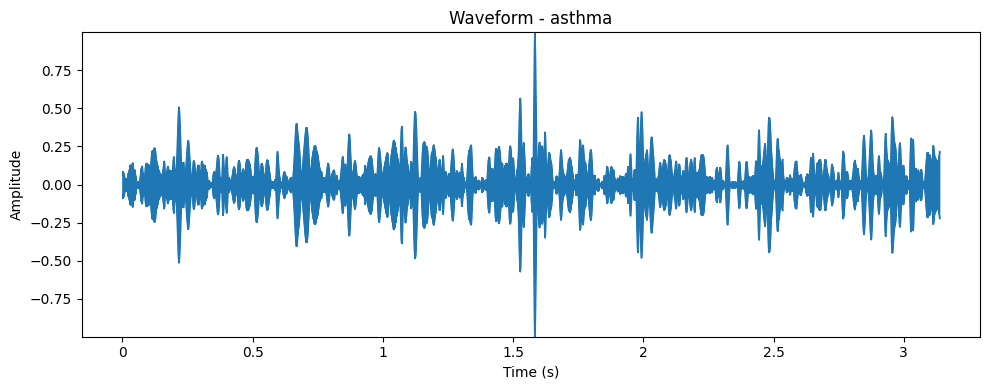

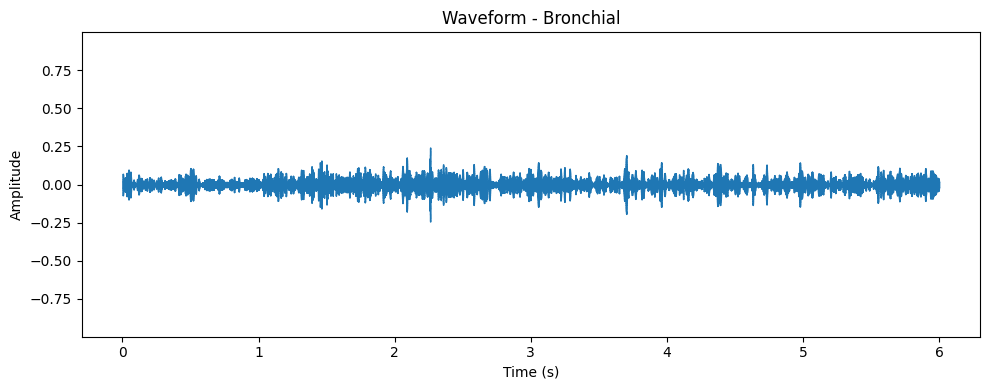

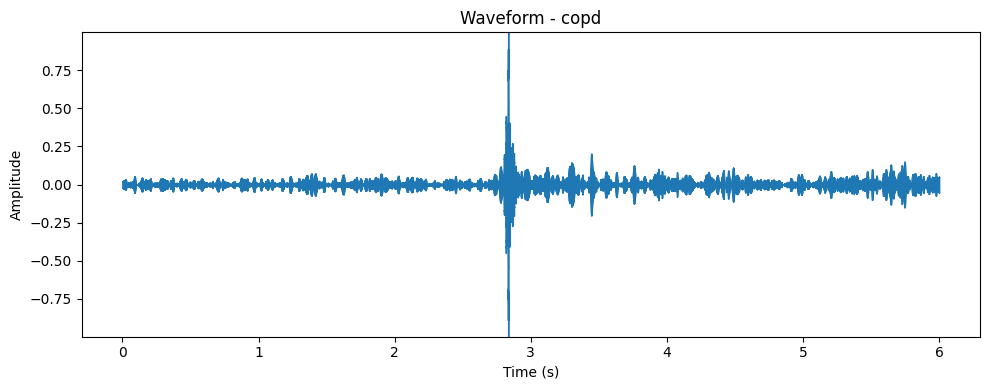

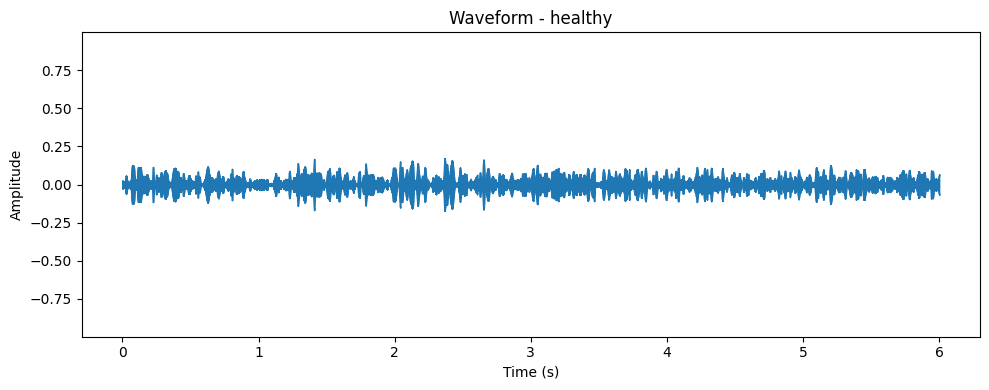

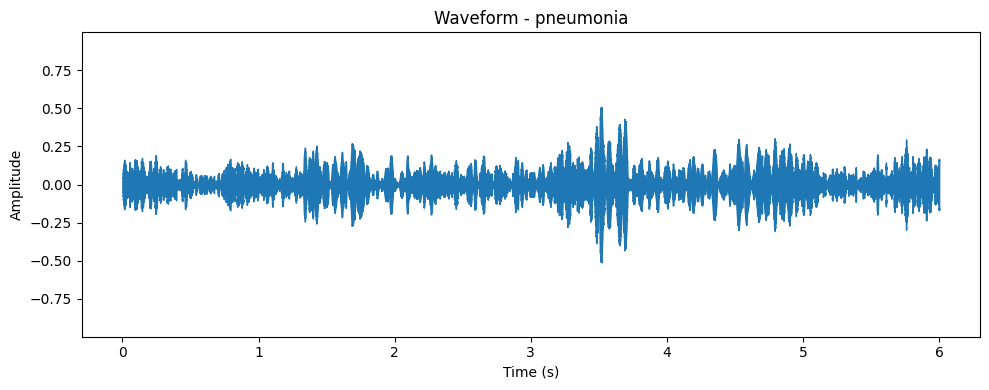

In [25]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import matplotlib.pyplot as plt
import numpy as np

# Install librosa in the notebook environment if missing
if importlib.util.find_spec("librosa") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "librosa"])

import librosa
import librosa.display

##############################################################################
# 5) SHOW 5 WAVEFORM PLOTS (ONE FROM EACH CATEGORY)
#    with normalized vertical scales across all categories
##############################################################################
base_data_dir = Path("data")

# Adapted to your folder architecture
category_dirs = [
    base_data_dir / "asthma",
    base_data_dir / "Bronchial",
    base_data_dir / "copd",
    base_data_dir / "healthy",
    base_data_dir / "pneumonia",
]

print("\n=== Waveform Examples for Each Category (Normalized Y scale) ===")

loaded_waveforms = []
for category_dir in category_dirs:
    if not category_dir.exists():
        print(f"Folder not found: {category_dir}")
        continue

    wav_files = sorted(category_dir.glob("*.wav"))
    if not wav_files:
        print(f"No .wav file in: {category_dir}")
        continue

    audio_path = wav_files[0]  # first file for this category
    y, sr = librosa.load(str(audio_path), sr=None)
    loaded_waveforms.append((category_dir.name, y, sr))

if loaded_waveforms:
    global_max_abs = max(float(np.max(np.abs(y))) for _, y, _ in loaded_waveforms)
    # Avoid invalid limits in edge cases (silent files)
    if global_max_abs == 0.0:
        global_max_abs = 1.0

    for category_name, y, sr in loaded_waveforms:
        plt.figure(figsize=(10, 4))
        librosa.display.waveshow(y, sr=sr)
        plt.ylim(-global_max_abs, global_max_abs)
        plt.title(f"Waveform - {category_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()


=== Mel Spectrogram Examples for Each Category (Normalized Color Scale) ===


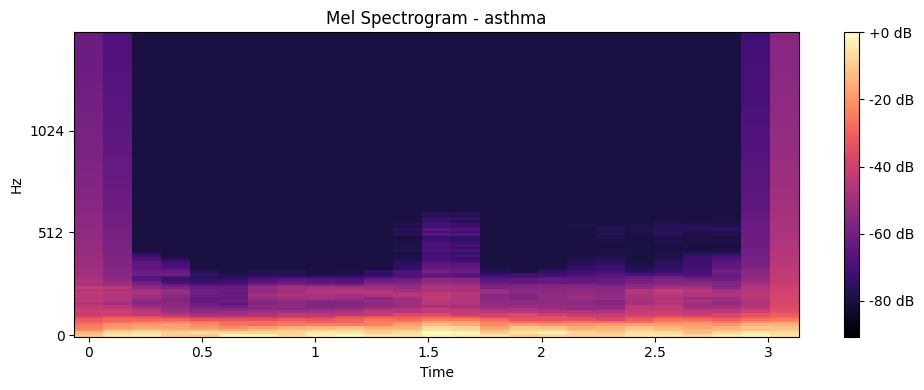

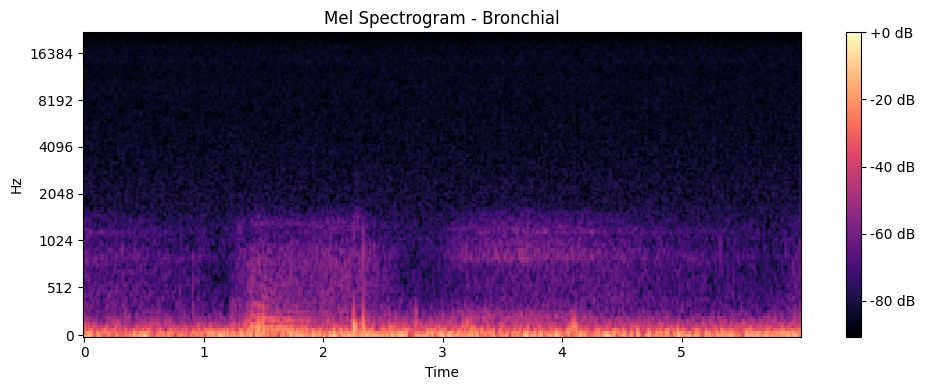

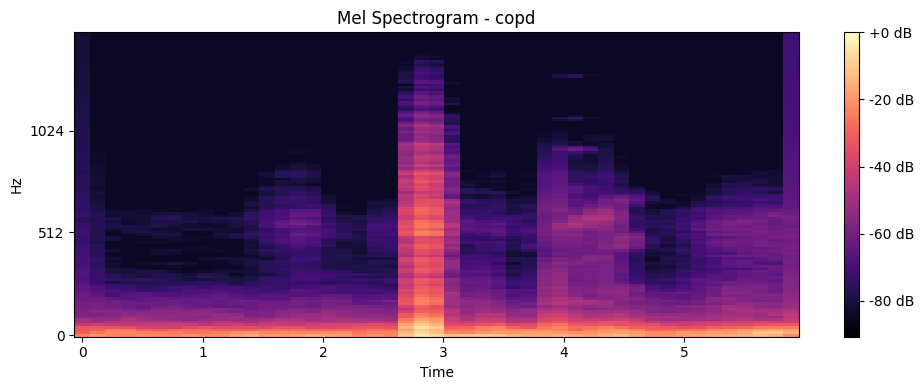

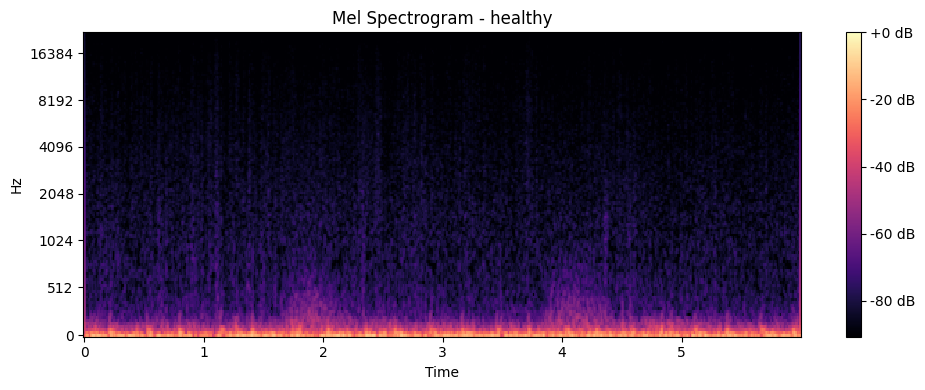

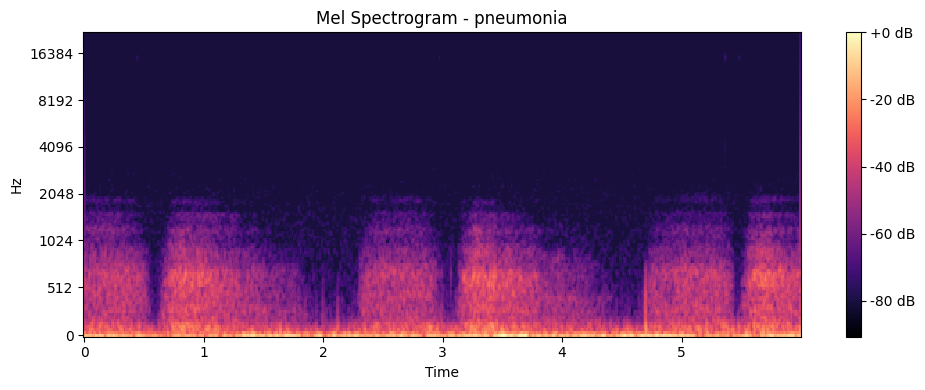

In [26]:
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

##############################################################################
# 6) SHOW 5 MEL SPECTROGRAMS (ONE FROM EACH CATEGORY)
#    with normalized color scale across all categories
##############################################################################
base_data_dir = Path("data")

category_dirs = [
    base_data_dir / "asthma",
    base_data_dir / "Bronchial",
    base_data_dir / "copd",
    base_data_dir / "healthy",
    base_data_dir / "pneumonia",
]

print("\n=== Mel Spectrogram Examples for Each Category (Normalized Color Scale) ===")

loaded_specs = []
for category_dir in category_dirs:
    if not category_dir.exists():
        print(f"Folder not found: {category_dir}")
        continue

    wav_files = sorted(category_dir.glob("*.wav"))
    if not wav_files:
        print(f"No .wav file in: {category_dir}")
        continue

    audio_path = wav_files[0]  # first file for this category
    y, sr = librosa.load(str(audio_path), sr=None)
    mel_power = librosa.feature.melspectrogram(y=y, sr=sr)
    loaded_specs.append((category_dir.name, mel_power, sr))

if loaded_specs:
    global_ref_power = max(float(np.max(mel_power)) for _, mel_power, _ in loaded_specs)

    mel_specs_db = [
        (category_name, librosa.power_to_db(mel_power, ref=global_ref_power), sr)
        for category_name, mel_power, sr in loaded_specs
    ]

    global_vmin = min(float(np.min(mel_db)) for _, mel_db, _ in mel_specs_db)
    global_vmax = 0.0

    for category_name, mel_db, sr in mel_specs_db:
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            mel_db,
            sr=sr,
            x_axis="time",
            y_axis="mel",
            vmin=global_vmin,
            vmax=global_vmax,
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Mel Spectrogram - {category_name}")
        plt.tight_layout()
        plt.show()

# Pré-traitement

In [ ]:
import librosa
import soundfile as sf
import os

target_sr = 4000

for file in os.listdir("data"):
    input_path = os.path.join("data", file)

    if os.path.isdir(input_path):
        output_dir = os.path.join("data_4k", file)
        os.makedirs(output_dir, exist_ok=True)

        for wav_name in os.listdir(input_path):
            if wav_name.lower().endswith(".wav"):
                src_path = os.path.join(input_path, wav_name)

                y, sr = librosa.load(src_path, sr=None)
                y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

                sf.write(os.path.join(output_dir, wav_name), y_resampled, target_sr)